In [41]:
import pandas as pd
ppl = pd.read_csv("resources/powerplants.csv", keep_default_na=False)   # path adjust
ppl.groupby("Fueltype")["Capacity"].sum()

Fueltype
Bioenergy        147.900000
CCGT          110174.332148
Geothermal      1220.000000
Hard Coal     117524.567894
Hydro          60001.553220
Lignite         4124.656785
Nuclear          621.000000
Oil            15755.348483
Waste             44.044540
Name: Capacity, dtype: float64

In [10]:
coal_ppl = ppl.loc[ppl.Fueltype.isin(["Hard Coal", "Lignite"]), ["Name", "Fueltype", "Country", "Capacity", "DateIn", "DateOut", "bus"]]
print(coal_ppl.sort_values("DateOut"))
print(coal_ppl[coal_ppl.DateOut.isna()])

                       Name   Fueltype Country  Capacity  DateIn  DateOut  \
755       Tpt Petrochemical  Hard Coal      TH      55.0  1995.0   2030.0   
215   Bukit Asam Muara Enim  Hard Coal      ID     260.0  1987.0   2030.0   
737  Sinar Mas Jambi Lontar  Hard Coal      ID     211.0  1994.0   2030.0   
753  Tjiwi Kimia Paper Mill  Hard Coal      ID     230.0  1992.0   2030.0   
60                   Paiton  Hard Coal      ID    4835.0  1993.0   2030.0   
..                      ...        ...     ...       ...     ...      ...   
720                Na Duong  Hard Coal      VN     110.0  2026.0   2050.0   
716         Long Phu Centre  Hard Coal      VN    1200.0  2026.0   2050.0   
744               Sumbagsel  Hard Coal      ID     300.0  2026.0   2050.0   
725              Parit Baru  Hard Coal      ID     100.0  2025.0   2050.0   
734      Quang Trach Center  Hard Coal      VN    1403.0  2026.0   2050.0   

      bus  
755   710  
215   347  
737  2360  
753   259  
60   2008  
.. 

In [10]:
import pypsa, glob, pandas as pd

# load all postnetwork files
paths = sorted(glob.glob("results/postnetworks/*.nc"))

rows = []

for p in paths:
    # try to extract the year (e.g. "_2030_" or "_2040_")
    year = None
    for y in ["2030","2035","2040","2045","2050"]:
        if y in p:
            year = int(y)
            break

    n = pypsa.Network(p)
    #print(f"Loaded {p}")

    # sum capacities for coal and lignite (both Generators and Links)
    carriers = ("coal", "lignite")
    total_mw = 0.0

    if not n.generators.empty:
        gen_mask = n.generators.carrier.str.lower().str.contains("|".join(carriers), na=False)
        total_mw += n.generators.loc[gen_mask, "p_nom"].sum()

    if not n.links.empty:
        link_mask = n.links.carrier.str.lower().str.contains("|".join(carriers), na=False)
        total_mw += n.links.loc[link_mask, "p_nom"].sum()

    rows.append({"year": year, "coal_lignite_MW": total_mw})

# build dataframe
df = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)

# compute relative % to 2030 baseline
baseline = df.loc[df["year"] == 2030, "coal_lignite_MW"].values[0]
df["relative_%"] = df["coal_lignite_MW"] / baseline * 100

print("\nCoal/Lignite capacity trend:")
print(df.to_string(index=False))


INFO:pypsa.network.io:New version 1.0.2 available! (Current: 0.35.1)
Index(['CO2 pipeline BN4 0 <-> MY4 0-2030',
       'CO2 pipeline ID1 0 <-> ID9 0-2030',
       'CO2 pipeline ID9 0 <-> MY2 0-2030',
       'CO2 pipeline ID9 0 <-> SG6 0-2030',
       'CO2 pipeline KH12 0 <-> TH12 0-2030',
       'CO2 pipeline KH8 0 <-> LA8 0-2030',
       'CO2 pipeline LA12 0 <-> TH12 0-2030',
       'CO2 pipeline LA8 0 <-> TH8 0-2030',
       'CO2 pipeline LA8 0 <-> VN8 0-2030',
       'CO2 pipeline MM12 0 <-> MM12 2-2030',
       'CO2 pipeline MM12 0 <-> MM12 3-2030',
       'CO2 pipeline MM12 0 <-> MM12 4-2030',
       'CO2 pipeline MM12 1 <-> MM12 4-2030',
       'CO2 pipeline MM12 1 <-> TH12 0-2030',
       'CO2 pipeline MM12 2 <-> MM12 4-2030',
       'CO2 pipeline MY2 0 <-> MY4 0-2030',
       'CO2 pipeline MY2 0 <-> SG43 0-2030',
       'CO2 pipeline MY3 0 <-> PH14 0-2030',
       'CO2 pipeline PH14 0 <-> PH16 0-2030',
       'CO2 pipeline PH15 0 <-> PH16 0-2030',
       'CO2 pipeline TH12 0 <


Coal/Lignite capacity trend:
 year  coal_lignite_MW  relative_%
 2030    728137.725326  100.000000
 2040    464161.286905   63.746359
 2050         0.000000    0.000000


In [30]:
n.buses.carrier.value_counts().loc[["gas","oil","coal"]].fillna(0)


carrier
gas     52
oil     52
coal    52
Name: count, dtype: int64

In [40]:
n.links.query('carrier.str.contains("oil|OCGT|CCGT|gas",case=False)', engine="python")[
    ["carrier","p_nom","p_nom_opt","p_nom_extendable","capital_cost","marginal_cost"]
].groupby("carrier").mean()


,p_nom,p_nom_opt,p_nom_extendable,capital_cost,marginal_cost
carrier,,,,,
CCGT,4636.054875,4636.055787,0.436975,60399.079294,2.575292
OCGT,1802.795745,2232.974060,0.675325,19487.738307,2.037924
biogas to gas,0.000000,58.913531,1.000000,33144.920081,2.709351
gas for industry,0.000000,664.237892,1.000000,0.000000,0.009980
gas for industry CC,0.000000,0.000836,1.000000,41274.868337,0.010070
oil,846.565137,846.565137,0.000000,13859.322004,2.242575
residential rural gas boiler,136.547562,137.008712,0.722222,40609.321683,0.015372
residential urban decentral gas boiler,156.905987,159.034064,0.838710,40154.245524,0.012785
services rural gas boiler,0.000000,0.000514,1.000000,39628.051349,0.010079


NameError: name 'plt' is not defined

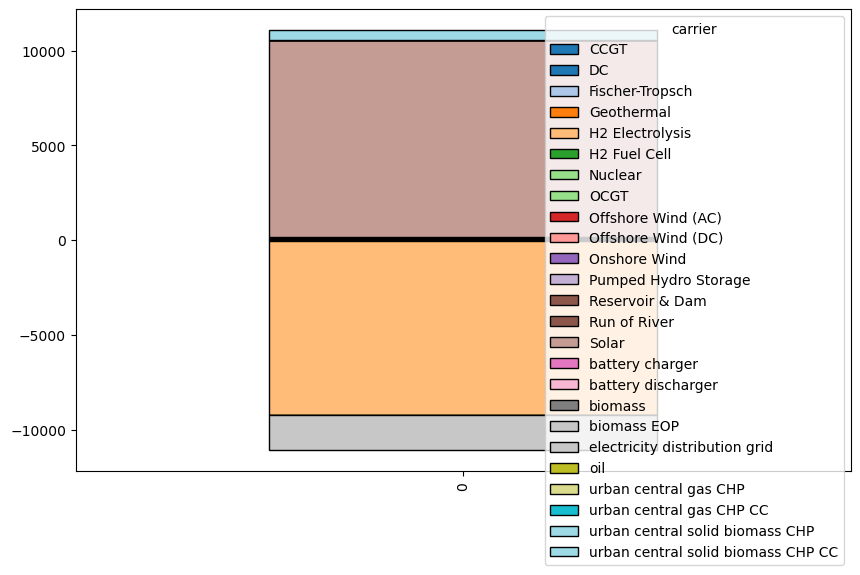

In [11]:

energy_balance = (
    n.statistics.energy_balance()
    .loc[:, :, "AC"]
    .groupby("carrier")
    .sum()
    .div(1e6)  # convert to TWh
    .to_frame()
    .T
    .rename(columns=rename_cols)
)
# Plot
ax = energy_balance.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="tab20",
    edgecolor="black"
)

# Styling
plt.title("Energy Balance by Carrier [TWh]", fontsize=14)
plt.ylabel("TWh")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Carrier", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

In [1]:
import pandas as pd
costs = pd.read_csv("resources/costs_2030.csv", index_col=0)
costs.head()


,parameter,value,unit,source,further description,currency_year
technology,,,,,,
Ammonia cracker,FOM,4.300000e+00,%/year,Ishimoto et al. (2020): 10.1016/j.ijhydene.202...,"Estimated based on Labour cost rate, Maintenan...",2015.0
Ammonia cracker,ammonia-input,1.460000e+00,MWh_NH3/MWh_H2,ENGIE et al (2020): Ammonia to Green Hydrogen ...,Assuming a integrated 200t/d cracking and puri...,NaN
Ammonia cracker,investment,1.123945e+06,EUR/MW_H2,Ishimoto et al. (2020): 10.1016/j.ijhydene.202...,Calculated. For a small (200 t_NH3/d input) fa...,2015.0
Ammonia cracker,lifetime,2.500000e+01,years,Ishimoto et al. (2020): 10.1016/j.ijhydene.202...,NaN,2015.0
BEV Bus city,FOM,3.000000e-04,%/year,"Danish Energy Agency, inputs/data_sheets_for_c...",BEV B1,2022.0


In [3]:
costs.loc[["solar","onwind","offwind","OCGT","CCGT"]]


,parameter,value,unit,source,further description,currency_year
technology,,,,,,
solar,FOM,1.9495,%/year,Calculated. See 'further description'.,Mixed investment costs based on average of 50%...,2020.0
solar,VOM,0.0106,EUR/MWhel,RES costs made up to fix curtailment order,from old pypsa cost assumptions,2015.0
solar,investment,543.3289,EUR/kW_e,Calculated. See 'further description'.,Mixed investment costs based on average of 50%...,2020.0
solar,lifetime,40.0000,years,Calculated. See 'further description'.,Mixed investment costs based on average of 50%...,2020.0
onwind,FOM,1.2167,%/year,"Danish Energy Agency, technology_data_for_el_a...",20 Onshore turbines: Fixed O&M,2015.0
onwind,VOM,1.4286,EUR/MWh,"Danish Energy Agency, technology_data_for_el_a...",20 Onshore turbines: Variable O&M,2015.0
onwind,investment,1095.8533,EUR/kW,"Danish Energy Agency, technology_data_for_el_a...",20 Onshore turbines: Nominal investment,2015.0
onwind,lifetime,30.0000,years,"Danish Energy Agency, technology_data_for_el_a...",20 Onshore turbines: Technical lifetime,2015.0
offwind,FOM,2.3185,%/year,"Danish Energy Agency, technology_data_for_el_a...","21 Offshore turbines: Fixed O&M [EUR/MW_e/y, ...",2020.0


In [4]:
# === INSPECT COSTS AND TECHNOLOGY PARAMETERS IN THE SYSTEM ===
import pypsa
import pandas as pd

# --- load the network ---
n = pypsa.Network("results/postnetworks/elec_s_60_ec_lcopt_Co2L-24h_24h_2050_0.05_ASEAN_0export.nc")

# --- basic overview ---
print("🧭 Network overview:")
print(f"buses: {len(n.buses)} | generators: {len(n.generators)} | links: {len(n.links)} | stores: {len(n.stores)} | lines: {len(n.lines)}")

# --- display techno-economic parameters actually used in the solved system ---
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# 1️⃣ generator technologies (renewables, fossil, etc.)
gen_costs = (
    n.generators
    .groupby("carrier")[["capital_cost","marginal_cost","lifetime"]]
    .mean()
    .sort_values("capital_cost")
)
print("\n⚡ Generator technologies (averaged by carrier):")
display(gen_costs)

# 2️⃣ link-based technologies (electrolysis, BECCS, fuel cells, etc.)
link_costs = (
    n.links
    .groupby("carrier")[["capital_cost","marginal_cost","efficiency"]]
    .mean()
    .sort_values("capital_cost")
)
print("\n🔗 Link-based technologies (averaged by carrier):")
display(link_costs)

# 3️⃣ stores (batteries, H₂ tanks, hydro, etc.)
store_costs = (
    n.stores
    .groupby("carrier")[["capital_cost","e_nom_opt"]]
    .mean()
    .sort_values("capital_cost")
)
print("\n💾 Storage technologies (averaged by carrier):")
display(store_costs)

# 4️⃣ optional: combined compact summary
summary = pd.concat({
    "Generators": gen_costs[["capital_cost","marginal_cost"]],
    "Links": link_costs[["capital_cost","marginal_cost"]],
    "Stores": store_costs[["capital_cost"]]
})
print("\n📊 Compact overview of all technology types:")
display(summary)

# --- sanity check: top 10 generation capacities by carrier ---
gen_caps = n.generators.groupby("carrier")["p_nom_opt"].sum().sort_values(ascending=False).head(10)/1e3
print("\n🏗️ Top 10 generation carriers by built capacity [GW]:")
display(gen_caps)


INFO:pypsa.network.io:New version 1.0.3 available! (Current: 0.35.1)
Index(['CO2 pipeline BN4 0 <-> MY4 0-2050',
       'CO2 pipeline ID1 0 <-> ID9 0-2050',
       'CO2 pipeline ID9 0 <-> MY2 0-2050',
       'CO2 pipeline ID9 0 <-> SG6 0-2050',
       'CO2 pipeline KH12 0 <-> TH12 0-2050',
       'CO2 pipeline KH8 0 <-> LA8 0-2050',
       'CO2 pipeline LA12 0 <-> TH12 0-2050',
       'CO2 pipeline LA8 0 <-> TH8 0-2050',
       'CO2 pipeline LA8 0 <-> VN8 0-2050',
       'CO2 pipeline LA8 0 <-> VN8 1-2050',
       'CO2 pipeline MM12 0 <-> MM12 2-2050',
       'CO2 pipeline MM12 0 <-> MM12 7-2050',
       'CO2 pipeline MM12 1 <-> MM12 4-2050',
       'CO2 pipeline MM12 1 <-> MM12 5-2050',
       'CO2 pipeline MM12 2 <-> MM12 4-2050',
       'CO2 pipeline MM12 2 <-> MM12 6-2050',
       'CO2 pipeline MM12 2 <-> MM12 7-2050',
       'CO2 pipeline MM12 3 <-> MM12 4-2050',
       'CO2 pipeline MM12 3 <-> MM12 7-2050',
       'CO2 pipeline MM12 4 <-> MM12 7-2050',
       'CO2 pipeline MM12 5

🧭 Network overview:
buses: 1320 | generators: 2222 | links: 3416 | stores: 884 | lines: 20

⚡ Generator technologies (averaged by carrier):


,capital_cost,marginal_cost,lifetime
carrier,,,
biomass,0.000,7.418,inf
load,0.000,100.010,inf
lignite,0.000,3.309,inf
oil,0.000,52.921,inf
gas,0.000,24.578,inf
coal,0.000,9.564,inf
urban central solar thermal,"16,058.523",3.010,20.000
residential rural solar thermal,"24,738.124",3.010,20.000
residential urban decentral solar thermal,"24,738.124",3.010,20.000



🔗 Link-based technologies (averaged by carrier):


,capital_cost,marginal_cost,efficiency
carrier,,,
B2B,0.000,0.010,1.000
solid biomass for industry,0.000,0.010,1.000
services urban decentral water tanks discharger,0.000,0.010,0.990
services urban decentral water tanks charger,0.000,0.010,0.990
services rural water tanks discharger,0.000,0.010,0.990
services rural water tanks charger,0.000,0.010,0.990
residential urban decentral water tanks discharger,0.000,0.010,0.990
residential urban decentral water tanks charger,0.000,0.010,0.990
residential rural water tanks discharger,0.000,0.010,0.990


...

,capital_cost,e_nom_opt
carrier,,
H2,0.000,0.000
services urban decentral water tanks,0.000,"1,267.607"
services rural water tanks,0.000,"1,306.590"
residential urban decentral water tanks,0.000,"61,653.786"
residential rural water tanks,0.000,"43,291.704"
oil,0.000,"19,313,532,096.812"
lignite,0.000,0.000
solid biomass,0.000,"1,089,000,000.000"
gas,0.000,"99,123,157,848.971"



📊 Compact overview of all technology types:


capital_cost  \
           carrier                                                            
Generators biomass                                                    0.000   
           load                                                       0.000   
           lignite                                                    0.000   
           oil                                                        0.000   
           gas                                                        0.000   
           coal                                                       0.000   
           urban central solar thermal                           16,058.523   
           residential rural solar thermal                       24,738.124   
           residential urban decentral solar thermal             24,738.124   
           services rural solar thermal                          24,738.124   
           services urban decentral solar thermal                24,738.124   
           solar                                                 35,285.681   
           solar rooftop                                         35,842.397   
           onwind                                               163,678.091   
           ror                                                  166,087.691   
           geothermal                                           309,224.930   
           offwind-ac                                           381,306.148   
           offwind-dc                                           446,532.818   
           nuclear                                              932,470.353   
Links      B2B                                                        0.000   
           solid biomass for industry                                 0.000   
           services urban decentral water tanks discharger            0.000   
           services urban decentral water tanks charger               0.000   
           services rural water tanks discharger                      0.000   
           services rural water tanks charger                         0.000   
           residential urban decentral water tanks discharger         0.000   
           residential urban decentral water tanks charger            0.000   
           residential rural water tanks discharger                   0.000   
           residential rural water tanks charger                      0.000   
           urban central water tanks charger                          0.000   
           process emissions                                          0.000   
           home battery discharger                                    0.000   
           gas for industry                                           0.000   
           curtailment                                                0.000   
           co2 vent                                                   0.000   
           urban central water tanks discharger                       0.000   
           H2 UHS charger                                             0.000   
           H2                                                         0.000   
           H2 UHS discharger                                          0.000   
           V2G                                                        0.000   
           BEV charger                                                0.000   
           battery discharger                                         0.000   
           urban central gas boiler                               6,596.674   
           urban central resistive heater                         6,898.999   
           services urban decentral resistive heater              8,912.724   
           services rural resistive heater                        8,912.724   
           residential rural resistive heater                     8,912.724   
           residential urban decentral resistive heater           8,912.724   
           battery charger                                        9,611.457   
           oil                    


🏗️ Top 10 generation carriers by built capacity [GW]:


carrier
load                              1,320,000,000.000
biomass                                   2,867.828
solar                                       218.078
solar rooftop                               139.760
gas                                          35.538
onwind                                       15.104
ror                                           9.403
offwind-dc                                    2.362
urban central solar thermal                   2.222
residential rural solar thermal               1.403
Name: p_nom_opt, dtype: float64